# Publication Landscape Analysis: Descriptive Baseline

**Purpose:** Establish quantitative baseline of the field's growth and composition.

This notebook applies classic bibliometric laws to characterize the subiculum literature:
- **Bradford's Law** — Journal distribution and core source identification
- **Lotka's Law** — Author productivity patterns
- **Temporal patterns** — Field growth and key events
- **Geographic & funding distribution** — Institutional landscape

**Outputs:**
- Publication-quality figures (Nature style) for LaTeX report
- Interactive Plotly visualizations for exploration
- Summary statistics (JSON) for reproducibility

---
## Setup

In [1]:
import sqlite3
import json
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import scienceplots
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.optimize import curve_fit
import sys
sys.path.append('../')
from utils import (
    query_db, 
    save_figure, 
    save_dataframe,
    save_figure_both_formats
)

plt.style.context(['science', 'no-latex', 'nature'])

TIMESTAMP = datetime.now().strftime('%Y-%m-%d')
DB_PATH = Path('../../data/raw/subiculum_literature.db')
IMGS_DIR = Path('imgs')
OUTPUTS_DIR = Path('outputs')

## Load Data

In [2]:
conn = sqlite3.connect(DB_PATH)

# Load papers with publication metadata
papers_query = """
SELECT 
    pmid,
    title,
    journal_name,
    pub_year,
    pub_date_full,
    abstract,
    doi
FROM papers
WHERE pub_year IS NOT NULL
ORDER BY pub_year
"""
papers_df = pd.read_sql_query(papers_query, conn)

# Load author-paper relationships
authors_query = """
SELECT 
    a.author_id,
    a.last_name,
    a.fore_name,
    pa.pmid,
    pa.author_position,
    pa.affiliation,
    p.pub_year
FROM authors a
JOIN paper_authors pa ON a.author_id = pa.author_id
JOIN papers p ON pa.pmid = p.pmid
WHERE p.pub_year IS NOT NULL
"""
authors_df = pd.read_sql_query(authors_query, conn)

# Load grant/funding information
grants_query = """
SELECT 
    g.agency,
    g.grant_number,
    g.country,
    pg.pmid,
    p.pub_year
FROM grants g
JOIN paper_grants pg ON g.grant_id = pg.grant_id
JOIN papers p ON pg.pmid = p.pmid
WHERE p.pub_year IS NOT NULL
"""
grants_df = pd.read_sql_query(grants_query, conn)

print(f"Loaded {len(papers_df):,} papers")
print(f"Loaded {len(authors_df):,} author-paper relationships")
print(f"Loaded {len(grants_df):,} grant-paper relationships")
print(f"Year range: {papers_df['pub_year'].min()}-{papers_df['pub_year'].max()}")

Loaded 3,572 papers
Loaded 20,508 author-paper relationships
Loaded 4,917 grant-paper relationships
Year range: 1966-2025


## Part 1: Publication Trends Over Time

Before applying bibliometric laws, let's establish the temporal baseline of the field's growth.

### 1.1 Annual Publication Counts

In [3]:
# Calculate annual publication counts
# Group by year, compute cumulative counts, moving averages, etc.
# Save to outputs/annual_publications.csv

# Calculate annual publication counts
papers_by_year = papers_df.groupby('pub_year').size().reset_index(name='count')

# Add cumulative count
papers_by_year['cumulative'] = papers_by_year['count'].cumsum()

# Calculate 5-year moving average
papers_by_year['ma_5yr'] = papers_by_year['count'].rolling(window=5, center=True).mean()

# Calculate decade groupings for summary
papers_df['decade'] = (papers_df['pub_year'] // 10) * 10
papers_by_decade = papers_df.groupby('decade').size().reset_index(name='count')
papers_by_decade['decade_label'] = papers_by_decade['decade'].astype(str) + 's'

# Summary statistics
total_papers = len(papers_df)
year_range = f"{papers_df['pub_year'].min()}-{papers_df['pub_year'].max()}"
recent_5yr = papers_df[papers_df['pub_year'] >= papers_df['pub_year'].max() - 4]
recent_5yr_count = len(recent_5yr)
recent_5yr_avg = recent_5yr_count / 5

print(f"Total papers: {total_papers:,}")
print(f"Year range: {year_range}")
print(f"Recent 5 years: {recent_5yr_count:,} papers ({recent_5yr_avg:.1f} per year)")
print(f"Peak year: {papers_by_year.loc[papers_by_year['count'].idxmax(), 'pub_year']:.0f} ({papers_by_year['count'].max()} papers)")

# Save to CSV
papers_by_year.to_csv(OUTPUTS_DIR / f'annual_publications_{TIMESTAMP}.csv', index=False)
papers_by_decade.to_csv(OUTPUTS_DIR / f'decade_publications_{TIMESTAMP}.csv', index=False)

print(f"\n✓ Saved: annual_publications_{TIMESTAMP}.csv")
print(f"✓ Saved: decade_publications_{TIMESTAMP}.csv")

# Display first/last few years
print("\nFirst 5 years:")
print(papers_by_year.head())
print("\nLast 5 years:")
print(papers_by_year.tail())

Total papers: 3,572
Year range: 1966-2025
Recent 5 years: 772 papers (154.4 per year)
Peak year: 2025 (174 papers)

✓ Saved: annual_publications_2025-12-08.csv
✓ Saved: decade_publications_2025-12-08.csv

First 5 years:
   pub_year  count  cumulative  ma_5yr
0      1966      1           1     NaN
1      1972      3           4     NaN
2      1974      2           6     3.6
3      1975      6          12     5.4
4      1976      6          18     6.8

Last 5 years:
    pub_year  count  cumulative  ma_5yr
49      2021    148        2948   130.6
50      2022    109        3057   139.2
51      2023    168        3225   154.4
52      2024    173        3398     NaN
53      2025    174        3572     NaN


### 1.2 Interactive Temporal Exploration (Plotly)

Interactive timeline for exploring publication dynamics over time.

In [4]:
# Create interactive Plotly timeline
# - Hoverable annual counts
# - Zoomable/pannable
# - Optional: overlay journal distribution over time
# - Save to outputs/pub_trends.html (if deemed shareable-worthy)
# Create interactive Plotly timeline
fig = go.Figure()

# Add annual publications as bars
fig.add_trace(go.Bar(
  x=papers_by_year['pub_year'],
  y=papers_by_year['count'],
  name='Annual Publications',
  marker_color='#2E86AB',
  opacity=0.7,
  hovertemplate='<b>Year: %{x}</b><br>' +
                'Publications: %{y}<br>' +
                '<extra></extra>'
))

# Add 5-year moving average as line
fig.add_trace(go.Scatter(
  x=papers_by_year['pub_year'],
  y=papers_by_year['ma_5yr'],
  name='5-Year Moving Average',
  line=dict(color='#A23B72', width=3),
  mode='lines',
  hovertemplate='<b>Year: %{x}</b><br>' +
                '5-yr avg: %{y:.1f}<br>' +
                '<extra></extra>'
))

# Update layout
fig.update_layout(
  title='Interactive Publication Timeline: Subiculum Research (1966-2025)',
  xaxis_title='Year',
  yaxis_title='Number of Publications',
  hovermode='x unified',
  template='plotly_white',
  height=500,
  font=dict(size=12),
  showlegend=True,
  legend=dict(
      yanchor="top",
      y=0.99,
      xanchor="left",
      x=0.01
  )
)

# Add range slider
fig.update_xaxes(
  rangeslider_visible=True,
  rangeselector=dict(
      buttons=list([
          dict(count=10, label="10y", step="year", stepmode="backward"),
          dict(count=20, label="20y", step="year", stepmode="backward"),
          dict(step="all", label="All")
      ])
  )
)

fig.show()

# Optionally save to HTML
html_path = OUTPUTS_DIR / f'pub_trends_{TIMESTAMP}.html'
fig.write_html(html_path)
print(f"\n✓ Saved interactive plot: {html_path.name}")
print("  (Can be opened in browser for exploration)")


✓ Saved interactive plot: pub_trends_2025-12-08.html
  (Can be opened in browser for exploration)


---
## Part 2: Bradford's Law — Journal Distribution Analysis

### Theory: Bradford's Law of Scattering

**Bradford's Law** describes how articles on a specific subject are scattered across journals:

> *"A small core of highly productive journals exists, followed by successively larger groups (zones) of journals that yield the same number of articles, but with exponentially increasing numbers of journals."*

#### Mathematical Formulation

If journals are ranked by productivity (number of articles published), Bradford's Law states that the number of journals in each successive zone follows a geometric progression:

$$
n_1 : n_2 : n_3 = 1 : n : n^2
$$

Where:
- $n_1$ = number of journals in the **core zone** (most productive)
- $n_2$ = number of journals in **zone 2** (moderately productive)
- $n_3$ = number of journals in **zone 3** (least productive)
- $n$ = Bradford multiplier (typically 3-5)

Each zone contributes approximately **the same number of articles**, but requires exponentially more journals to find them.

#### Practical Implications

- **Core journals** (Zone 1): ~10-30 journals contain 1/3 of all relevant articles
- **Zone 2**: 3-5× more journals contribute another 1/3 of articles
- **Zone 3**: 9-25× more journals contribute final 1/3 of articles

This explains the **diminishing returns of literature searching**: you find most relevant articles in a few core journals, then need many more peripheral journals to find the same amount of new information.

#### Visualization Strategy

We'll create two visualizations:
1. **Bradford curve** (cumulative articles vs. log(journal rank)) — should show linear segments
2. **Zone distribution** — bar chart showing journals and articles per zone

Let's apply this to the subiculum literature.

### 2.1 Compute Journal Productivity Distribution

In [5]:
# Count papers per journal
# Rank journals by productivity
# Compute cumulative article counts
# Save to outputs/journal_productivity.csv
# Count papers per journal
journal_counts = papers_df.groupby('journal_name').size().reset_index(name='paper_count')

# Rank journals by productivity (descending)
journal_counts = journal_counts.sort_values('paper_count', ascending=False).reset_index(drop=True)
journal_counts['rank'] = journal_counts.index + 1

# Compute cumulative article counts
journal_counts['cumulative_papers'] = journal_counts['paper_count'].cumsum()
total_papers = journal_counts['paper_count'].sum()
journal_counts['cumulative_percentage'] = (journal_counts['cumulative_papers'] / total_papers) * 100

# Add log rank for Bradford curve
journal_counts['log_rank'] = np.log10(journal_counts['rank'])

# Summary statistics
n_journals = len(journal_counts)
print(f"Total journals: {n_journals:,}")
print(f"Total papers: {total_papers:,}")
print(f"Average papers per journal: {total_papers/n_journals:.1f}")
print(f"Median papers per journal: {journal_counts['paper_count'].median():.0f}")
print(f"\nTop 10 journals:")
print(journal_counts[['rank', 'journal_name', 'paper_count', 'cumulative_percentage']].head(10).to_string(index=False))

# Save to CSV
journal_counts.to_csv(OUTPUTS_DIR / f'journal_productivity_{TIMESTAMP}.csv', index=False)
print(f"\n✓ Saved: journal_productivity_{TIMESTAMP}.csv")

Total journals: 592
Total papers: 3,572
Average papers per journal: 6.0
Median papers per journal: 2

Top 10 journals:
 rank                                                                       journal_name  paper_count  cumulative_percentage
    1                                                                     Brain research          218               6.103024
    2                                               The Journal of comparative neurology          212              12.038074
    3                                                                       Neuroscience          166              16.685330
    4                                                                        Hippocampus          128              20.268757
    5 The Journal of neuroscience : the official journal of the Society for Neuroscience          122              23.684211
    6                                               The European journal of neuroscience           65              25.503919
    7 

### 2.2 Identify Bradford Zones

Divide journals into three zones, each contributing ~1/3 of total articles.

In [6]:
# Calculate zone boundaries
# - Zone 1: journals contributing first 1/3 of articles
# - Zone 2: journals contributing second 1/3
# - Zone 3: journals contributing final 1/3
# 
# Compute Bradford multiplier: n = n2/n1 and verify n3/n2 ≈ n
# Save zone assignments to outputs/bradford_zones.csv
# Divide journals into three zones, each contributing ~1/3 of total articles
zone_threshold = total_papers / 3

# Find zone boundaries
zone1_papers = 0
zone2_papers = 0
zone3_papers = 0
zone1_journals = 0
zone2_journals = 0
zone3_journals = 0

for idx, row in journal_counts.iterrows():
  if zone1_papers < zone_threshold:
      zone1_papers += row['paper_count']
      zone1_journals += 1
      journal_counts.loc[idx, 'zone'] = 1
  elif zone2_papers < zone_threshold:
      zone2_papers += row['paper_count']
      zone2_journals += 1
      journal_counts.loc[idx, 'zone'] = 2
  else:
      zone3_papers += row['paper_count']
      zone3_journals += 1
      journal_counts.loc[idx, 'zone'] = 3

# Calculate Bradford multiplier
# Theoretical: n2/n1 ≈ n3/n2 ≈ n (Bradford multiplier)
bradford_multiplier_1 = zone2_journals / zone1_journals if zone1_journals > 0 else 0
bradford_multiplier_2 = zone3_journals / zone2_journals if zone2_journals > 0 else 0

# Create zone summary
zone_summary = pd.DataFrame({
  'Zone': [1, 2, 3],
  'Journals': [zone1_journals, zone2_journals, zone3_journals],
  'Papers': [zone1_papers, zone2_papers, zone3_papers],
  'Papers_pct': [zone1_papers/total_papers*100, zone2_papers/total_papers*100, zone3_papers/total_papers*100],
  'Avg_papers_per_journal': [zone1_papers/zone1_journals if zone1_journals > 0 else 0,
                              zone2_papers/zone2_journals if zone2_journals > 0 else 0,
                              zone3_papers/zone3_journals if zone3_journals > 0 else 0]
})

print("\n" + "="*60)
print("BRADFORD'S LAW ANALYSIS")
print("="*60)
print("\nZone Distribution:")
print(zone_summary.to_string(index=False))

print(f"\nBradford Multipliers:")
print(f"  Zone 2 / Zone 1: {bradford_multiplier_1:.2f}")
print(f"  Zone 3 / Zone 2: {bradford_multiplier_2:.2f}")
print(f"  Average multiplier: {(bradford_multiplier_1 + bradford_multiplier_2) / 2:.2f}")

print(f"\nTheoretical pattern (1:n:n²): 1:{bradford_multiplier_1:.1f}:{bradford_multiplier_1**2:.1f}")
print(f"Observed pattern: 1:{bradford_multiplier_1:.1f}:{zone3_journals/zone1_journals:.1f}")

print(f"\n✓ Core journals (Zone 1): {zone1_journals} journals contain {zone1_papers} papers ({zone1_papers/total_papers*100:.1f}%)")
print(f"✓ Zone 2: {zone2_journals} journals contain {zone2_papers} papers ({zone2_papers/total_papers*100:.1f}%)")
print(f"✓ Zone 3: {zone3_journals} journals contain {zone3_papers} papers ({zone3_papers/total_papers*100:.1f}%)")

# Save zone assignments
journal_counts.to_csv(OUTPUTS_DIR / f'bradford_zones_{TIMESTAMP}.csv', index=False)
zone_summary.to_csv(OUTPUTS_DIR / f'bradford_zone_summary_{TIMESTAMP}.csv', index=False)

print(f"\n✓ Saved: bradford_zones_{TIMESTAMP}.csv")
print(f"✓ Saved: bradford_zone_summary_{TIMESTAMP}.csv")

# Show core journals (Zone 1)
print(f"\n{'='*60}")
print(f"CORE JOURNALS (Zone 1) - {zone1_journals} journals")
print("="*60)
core_journals = journal_counts[journal_counts['zone'] == 1][['rank', 'journal_name', 'paper_count']]
print(core_journals.to_string(index=False))


BRADFORD'S LAW ANALYSIS

Zone Distribution:
 Zone  Journals  Papers  Papers_pct  Avg_papers_per_journal
    1        12    1218   34.098544              101.500000
    2        62    1197   33.510638               19.306452
    3       518    1157   32.390817                2.233591

Bradford Multipliers:
  Zone 2 / Zone 1: 5.17
  Zone 3 / Zone 2: 8.35
  Average multiplier: 6.76

Theoretical pattern (1:n:n²): 1:5.2:26.7
Observed pattern: 1:5.2:43.2

✓ Core journals (Zone 1): 12 journals contain 1218 papers (34.1%)
✓ Zone 2: 62 journals contain 1197 papers (33.5%)
✓ Zone 3: 518 journals contain 1157 papers (32.4%)

✓ Saved: bradford_zones_2025-12-08.csv
✓ Saved: bradford_zone_summary_2025-12-08.csv

CORE JOURNALS (Zone 1) - 12 journals
 rank                                                                       journal_name  paper_count
    1                                                                     Brain research          218
    2                                             

### 2.3 Conceptual Explanation: How Bradford's Law Works

Create a simple illustration showing the 1:n:n² pattern.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved PNG: imgs/01_baseline_2025-12-08_bradford_concept.png
✅ Saved EPS: imgs/01_baseline_2025-12-08_bradford_concept.eps


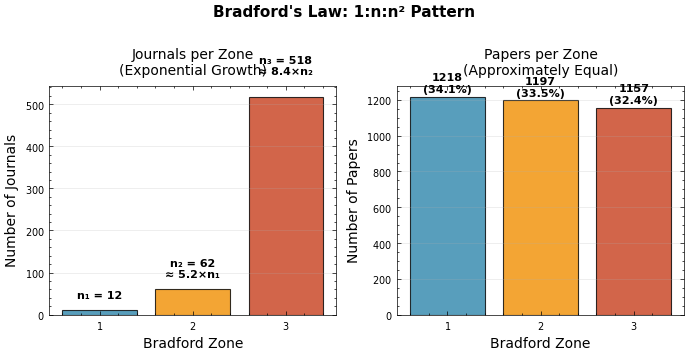

In [7]:
# Create conceptual figure:
# - Three bars showing number of journals in each zone
# - Annotate with 1:n:n² ratios
# - Equal-height bars showing each zone contributes ~same articles
# Save to imgs/01_baseline_{TIMESTAMP}_bradford_concept.png
# Create conceptual figure showing the 1:n:n² pattern

with plt.style.context(['science', 'no-latex', 'nature']):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 3.5))
    
    # Left panel: Number of journals per zone (showing exponential growth)
    zones = [1, 2, 3]
    journal_counts_per_zone = [zone1_journals, zone2_journals, zone3_journals]
    colors = ['#2E86AB', '#F18F01', '#C73E1D']
    
    bars1 = ax1.bar(zones, journal_counts_per_zone, color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)
    ax1.set_xlabel('Bradford Zone', fontsize=10)
    ax1.set_ylabel('Number of Journals', fontsize=10)
    ax1.set_title('Journals per Zone\n(Exponential Growth)', fontsize=10, pad=8)
    ax1.set_xticks(zones)
    ax1.grid(axis='y', alpha=0.3)
    
    # Annotate with ratios
    ax1.text(1, zone1_journals + max(journal_counts_per_zone)*0.05,
           f'n₁ = {zone1_journals}', ha='center', fontsize=8, weight='bold')
    ax1.text(2, zone2_journals + max(journal_counts_per_zone)*0.05,
           f'n₂ = {zone2_journals}\n≈ {bradford_multiplier_1:.1f}×n₁',
           ha='center', fontsize=8, weight='bold')
    ax1.text(3, zone3_journals + max(journal_counts_per_zone)*0.1,
           f'n₃ = {zone3_journals}\n≈ {bradford_multiplier_2:.1f}×n₂',
           ha='center', fontsize=8, weight='bold')
    
    # Right panel: Papers per zone (showing equal contributions)
    papers_per_zone = [zone1_papers, zone2_papers, zone3_papers]
    
    bars2 = ax2.bar(zones, papers_per_zone, color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)
    ax2.set_xlabel('Bradford Zone', fontsize=10)
    ax2.set_ylabel('Number of Papers', fontsize=10)
    ax2.set_title('Papers per Zone\n(Approximately Equal)', fontsize=10, pad=8)
    ax2.set_xticks(zones)
    ax2.grid(axis='y', alpha=0.3)
    
    # Annotate with paper counts
    for i, (zone, count) in enumerate(zip(zones, papers_per_zone)):
      ax2.text(zone, count + max(papers_per_zone)*0.02,
               f'{count}\n({count/total_papers*100:.1f}%)',
               ha='center', fontsize=8, weight='bold')


    plt.suptitle("Bradford's Law: 1:n:n² Pattern", fontsize=11, y=1.02, weight='bold')
    plt.tight_layout()
    
    # Save both formats
    filename = f'01_baseline_{TIMESTAMP}_bradford_concept'
    save_figure_both_formats(fig, filename, IMGS_DIR)
    plt.show()


### 2.4 Bradford Curve (Nature Style)

Classic Bradford plot: cumulative articles vs. log(journal rank).

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved PNG: imgs/01_baseline_2025-12-08_bradford_curve.png
✅ Saved EPS: imgs/01_baseline_2025-12-08_bradford_curve.eps


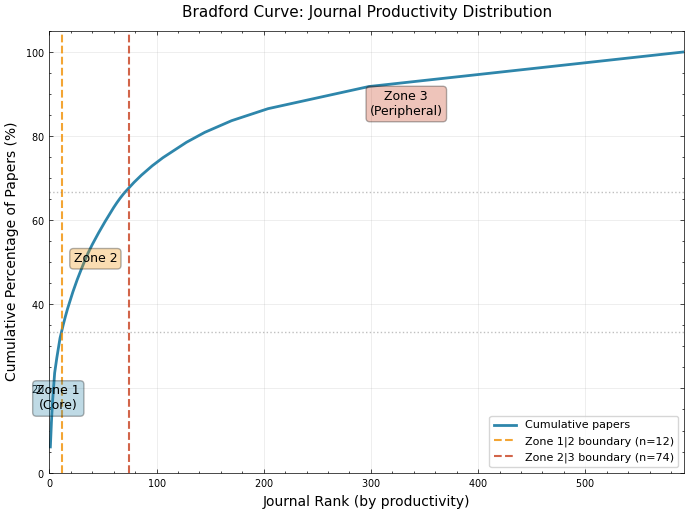

In [8]:
# Create Bradford curve:
# - X-axis: log(journal rank) or sequential journal rank
# - Y-axis: cumulative percentage of articles
# - Mark zone boundaries with vertical lines
# - Should show characteristic "S-curve" or piecewise linear segments
# Save to imgs/01_baseline_{TIMESTAMP}_bradford_curve.png
# Create Bradford curve: cumulative articles vs. journal rank

with plt.style.context(['science', 'no-latex', 'nature']):
    fig, ax = plt.subplots(figsize=(7.0, 5.25))
    
    # Plot cumulative percentage curve
    ax.plot(journal_counts['rank'], journal_counts['cumulative_percentage'],
          linewidth=2, color='#2E86AB', label='Cumulative papers')
    
    # Mark zone boundaries with vertical lines
    zone1_boundary = zone1_journals
    zone2_boundary = zone1_journals + zone2_journals
    
    ax.axvline(zone1_boundary, color='#F18F01', linestyle='--', linewidth=1.5,
             label=f'Zone 1|2 boundary (n={zone1_journals})', alpha=0.8)
    ax.axvline(zone2_boundary, color='#C73E1D', linestyle='--', linewidth=1.5,
             label=f'Zone 2|3 boundary (n={zone2_boundary})', alpha=0.8)
    
    # Add horizontal lines at 33% and 67%
    ax.axhline(33.33, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.axhline(66.67, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    # Formatting
    ax.set_xlabel('Journal Rank (by productivity)', fontsize=10)
    ax.set_ylabel('Cumulative Percentage of Papers (%)', fontsize=10)
    ax.set_title("Bradford Curve: Journal Productivity Distribution", fontsize=11, pad=10)
    ax.legend(frameon=True, fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, n_journals)
    ax.set_ylim(0, 105)
    
    # Annotate zones
    ax.text(zone1_journals * 0.7, 15, 'Zone 1\n(Core)', ha='center', fontsize=9,
          bbox=dict(boxstyle='round', facecolor='#2E86AB', alpha=0.3))
    ax.text((zone1_journals + zone2_boundary)/2, 50, 'Zone 2', ha='center', fontsize=9,
          bbox=dict(boxstyle='round', facecolor='#F18F01', alpha=0.3))
    ax.text((zone2_boundary + n_journals)/2, 85, 'Zone 3\n(Peripheral)', ha='center', fontsize=9,
          bbox=dict(boxstyle='round', facecolor='#C73E1D', alpha=0.3))
    
    plt.tight_layout()
    
    # Save both formats
    filename = f'01_baseline_{TIMESTAMP}_bradford_curve'
    save_figure_both_formats(fig, filename, IMGS_DIR)
    plt.show()


### 2.5 Zone Distribution (Nature Style)

Bar chart showing journals and articles per Bradford zone.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved PNG: imgs/01_baseline_2025-12-08_bradford_zones.png
✅ Saved EPS: imgs/01_baseline_2025-12-08_bradford_zones.eps


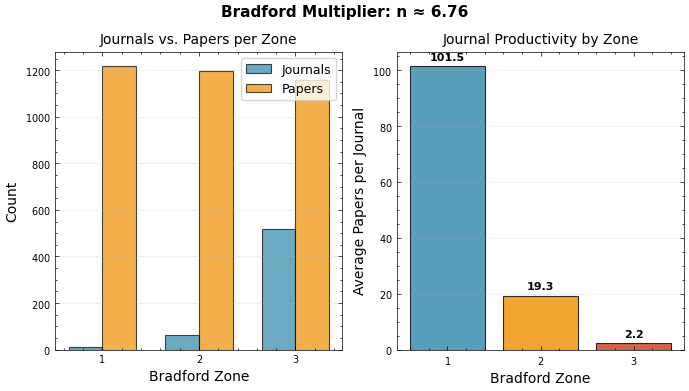

In [9]:
# Create zone distribution figure:
# - Grouped bar chart: journals per zone vs articles per zone
# - Annotate with Bradford multiplier
# - Table showing core journals in Zone 1
# Save to imgs/01_baseline_{TIMESTAMP}_bradford_zones.png

# Create zone distribution figure with grouped bars
with plt.style.context(['science', 'no-latex', 'nature']):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 4.0))

  zones = [1, 2, 3]
  colors = ['#2E86AB', '#F18F01', '#C73E1D']

  # Left panel: Journals and Papers per zone
  x = np.arange(len(zones))
  width = 0.35

  bars1 = ax1.bar(x - width/2, [zone1_journals, zone2_journals, zone3_journals],
                  width, label='Journals', color=colors[0], alpha=0.7, edgecolor='black', linewidth=0.8)
  bars2 = ax1.bar(x + width/2, [zone1_papers, zone2_papers, zone3_papers],
                  width, label='Papers', color=colors[1], alpha=0.7, edgecolor='black', linewidth=0.8)

  ax1.set_xlabel('Bradford Zone', fontsize=10)
  ax1.set_ylabel('Count', fontsize=10)
  ax1.set_title('Journals vs. Papers per Zone', fontsize=10)
  ax1.set_xticks(x)
  ax1.set_xticklabels(zones)
  ax1.legend(frameon=True, fontsize=9)
  ax1.grid(axis='y', alpha=0.3)

  # Right panel: Average productivity per zone
  avg_productivity = [zone1_papers/zone1_journals,
                     zone2_papers/zone2_journals,
                     zone3_papers/zone3_journals]

  bars3 = ax2.bar(zones, avg_productivity, color=colors, alpha=0.8,
                  edgecolor='black', linewidth=0.8)
  ax2.set_xlabel('Bradford Zone', fontsize=10)
  ax2.set_ylabel('Average Papers per Journal', fontsize=10)
  ax2.set_title('Journal Productivity by Zone', fontsize=10)
  ax2.set_xticks(zones)
  ax2.grid(axis='y', alpha=0.3)

  # Annotate bars with values
  for i, (zone, val) in enumerate(zip(zones, avg_productivity)):
      ax2.text(zone, val + max(avg_productivity)*0.02,
              f'{val:.1f}', ha='center', fontsize=8, weight='bold')

  plt.suptitle(f"Bradford Multiplier: n ≈ {(bradford_multiplier_1 + bradford_multiplier_2)/2:.2f}",
               fontsize=11, y=0.98, weight='bold')
  plt.tight_layout()

  # Save both formats
  filename = f'01_baseline_{TIMESTAMP}_bradford_zones'
  save_figure_both_formats(fig, filename, IMGS_DIR)
  plt.show()


### 2.6 Interactive Journal Explorer (Plotly)

Interactive visualization for exploring journal distribution.

In [ ]:
# Create interactive Plotly figure:
# - Hoverable Bradford curve
# - Click to see journal details
# - Color-coded by zone
# - Save to outputs/journal_zones.html (if deemed shareable-worthy)


# Create interactive Plotly figure for journal exploration
# Add zone as categorical column for coloring
journal_counts['zone_label'] = journal_counts['zone'].map({1: 'Zone 1 (Core)',
                                                           2: 'Zone 2 (Middle)',
                                                           3: 'Zone 3 (Peripheral)'})

fig = go.Figure()

# Add Bradford curve with color-coded zones
for zone_num in [1, 2, 3]:
  zone_data = journal_counts[journal_counts['zone'] == zone_num]
  zone_colors = {1: '#2E86AB', 2: '#F18F01', 3: '#C73E1D'}

  fig.add_trace(go.Scatter(
      x=zone_data['rank'],
      y=zone_data['cumulative_percentage'],
      mode='lines+markers',
      name=zone_data['zone_label'].iloc[0],
      line=dict(color=zone_colors[zone_num], width=2),
      marker=dict(size=4),
      customdata=zone_data[['journal_name', 'paper_count']],
      hovertemplate='<b>%{customdata[0]}</b><br>' +
                    'Rank: %{x}<br>' +
                    'Papers: %{customdata[1]}<br>' +
                    'Cumulative: %{y:.1f}%<br>' +
                    '<extra></extra>'
  ))

# Add zone boundary lines
fig.add_vline(x=zone1_journals, line_dash="dash", line_color="gray",
            annotation_text=f"Zone 1|2 (n={zone1_journals})",
            annotation_position="top")
fig.add_vline(x=zone1_journals + zone2_journals, line_dash="dash", line_color="gray",
            annotation_text=f"Zone 2|3 (n={zone1_journals + zone2_journals})",
            annotation_position="top")

# Update layout
fig.update_layout(
  title=f'Interactive Bradford Curve (Multiplier: n ≈ {(bradford_multiplier_1 + bradford_multiplier_2)/2:.2f})',
  xaxis_title='Journal Rank (by productivity)',
  yaxis_title='Cumulative Percentage of Papers (%)',
  hovermode='closest',
  template='plotly_white',
  height=600,
  font=dict(size=12),
  showlegend=True,
  legend=dict(
      yanchor="bottom",
      y=0.02,
      xanchor="right",
      x=0.98
  )
)

fig.update_xaxes(range=[0, n_journals])
fig.update_yaxes(range=[0, 105])

fig.show()

# Save to HTML
html_path = OUTPUTS_DIR / f'journal_zones_{TIMESTAMP}.html'
fig.write_html(html_path)
print(f"\n✓ Saved interactive plot: {html_path.name}")
print("  (Hover over points to see journal details)")

---
## Part 3: Lotka's Law — Author Productivity Analysis

### Theory: Lotka's Law of Scientific Productivity

**Lotka's Law** is an empirical law in bibliometrics describing the distribution of author productivity:

> *"The frequency of authors who publish a given number of papers is inversely proportional to the square of the number of papers."*

#### Mathematical Formulation

If $A_n$ is the number of authors who published exactly $n$ papers, then:

$$
A_n = \frac{A_1}{n^\alpha}
$$

Where:
- $A_1$ = number of authors with exactly 1 paper
- $n$ = number of papers
- $\alpha$ = Lotka exponent (theoretically 2, often ~1.9-2.5 empirically)

When $\alpha = 2$ (the classical "inverse square law"):

$$
A_n = \frac{A_1}{n^2}
$$

This means:
- Authors with 2 papers: $A_1/4$ (25%)
- Authors with 3 papers: $A_1/9$ (11%)
- Authors with 4 papers: $A_1/16$ (6%)
- And so on...

#### Practical Implications

- **~60% of authors publish only once** (one-time contributors)
- A small elite (< 1%) are highly productive (10+ papers)
- Describes the **uneven distribution of scientific productivity** across a field
- Useful for identifying "core contributors" vs. "transient contributors"

#### Testing Lotka's Law

We'll:
1. Count papers per author
2. Plot log(authors) vs. log(papers) — should yield straight line with slope ≈ -2
3. Fit power law to estimate $\alpha$ and test goodness-of-fit
4. Compare to theoretical Lotka distribution

Let's analyze author productivity in the subiculum literature.

### 3.1 Compute Author Productivity Distribution

In [10]:
# Count papers per author
# Create productivity distribution: number of authors with n papers
# Compute percentage of one-time contributors
# Save to outputs/author_productivity.csv

# Count papers per author
# Create full name for author identification
authors_df['full_name'] = authors_df.apply(
  lambda x: f"{x['last_name']}, {x['fore_name']}" if pd.notna(x['fore_name'])
  else x['last_name'],
  axis=1
)

# Count papers per author
author_productivity = authors_df.groupby('author_id')['pmid'].nunique().reset_index()
author_productivity.columns = ['author_id', 'paper_count']

# Add author names
author_names = authors_df[['author_id', 'full_name', 'last_name', 'fore_name']].drop_duplicates('author_id')
author_productivity = author_productivity.merge(author_names, on='author_id')

# Create productivity distribution: number of authors with n papers
productivity_dist = author_productivity.groupby('paper_count').size().reset_index(name='author_count')
productivity_dist = productivity_dist.sort_values('paper_count')

# Calculate percentages
total_authors = len(author_productivity)
productivity_dist['percentage'] = (productivity_dist['author_count'] / total_authors) * 100
productivity_dist['cumulative_authors'] = productivity_dist['author_count'].cumsum()
productivity_dist['cumulative_percentage'] = (productivity_dist['cumulative_authors'] / total_authors) * 100

# One-time contributors
one_time = productivity_dist[productivity_dist['paper_count'] == 1]['author_count'].values[0]
one_time_pct = (one_time / total_authors) * 100

print("="*60)
print("LOTKA'S LAW ANALYSIS")
print("="*60)
print(f"\nTotal unique authors: {total_authors:,}")
print(f"One-time contributors: {one_time:,} ({one_time_pct:.1f}%)")
print(f"Papers per author range: {author_productivity['paper_count'].min()}-{author_productivity['paper_count'].max()}")
print(f"Mean papers per author: {author_productivity['paper_count'].mean():.2f}")
print(f"Median papers per author: {author_productivity['paper_count'].median():.0f}")

print("\nProductivity distribution (first 10 bins):")
print(productivity_dist.head(10).to_string(index=False))

# Save to CSV
author_productivity.to_csv(OUTPUTS_DIR / f'author_productivity_{TIMESTAMP}.csv', index=False)
productivity_dist.to_csv(OUTPUTS_DIR / f'productivity_distribution_{TIMESTAMP}.csv', index=False)

print(f"\n✓ Saved: author_productivity_{TIMESTAMP}.csv")
print(f"✓ Saved: productivity_distribution_{TIMESTAMP}.csv")

LOTKA'S LAW ANALYSIS

Total unique authors: 15,599
One-time contributors: 12,996 (83.3%)
Papers per author range: 1-27
Mean papers per author: 1.31
Median papers per author: 1

Productivity distribution (first 10 bins):
 paper_count  author_count  percentage  cumulative_authors  cumulative_percentage
           1         12996   83.313033               12996              83.313033
           2          1629   10.442977               14625              93.756010
           3           480    3.077120               15105              96.833130
           4           226    1.448811               15331              98.281941
           5           102    0.653888               15433              98.935829
           6            67    0.429515               15500              99.365344
           7            24    0.153856               15524              99.519200
           8            16    0.102571               15540              99.621771
           9            26    0.166677    

### 3.2 Fit Lotka's Law (Power Law Estimation)

Estimate the Lotka exponent $\alpha$ using log-log regression.

In [11]:
# Fit power law: log(A_n) = log(A_1) - α * log(n)
# - Use linear regression on log-log transformed data
# - Estimate α and compute R²
# - Compare α to theoretical value of 2.0
# - Perform goodness-of-fit test (Kolmogorov-Smirnov)

# Fit power law: log(A_n) = log(A_1) - α * log(n)
# Use linear regression on log-log transformed data

# Filter out zeros for log transformation
fit_data = productivity_dist[productivity_dist['author_count'] > 0].copy()

# Log-log transformation
fit_data['log_papers'] = np.log10(fit_data['paper_count'])
fit_data['log_authors'] = np.log10(fit_data['author_count'])

# Linear regression on log-log data
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(
  fit_data['log_papers'],
  fit_data['log_authors']
)

# Lotka exponent (alpha) is negative of slope
alpha = -slope
r_squared = r_value ** 2

print("\n" + "="*60)
print("POWER LAW FIT (Lotka's Law)")
print("="*60)
print(f"Fitted exponent (α): {alpha:.3f}")
print(f"Theoretical α: 2.0")
print(f"Difference from theory: {abs(alpha - 2.0):.3f}")
print(f"R²: {r_squared:.4f}")
print(f"p-value: {p_value:.2e}")
print(f"Standard error: {std_err:.4f}")

# Calculate theoretical Lotka distribution for comparison
A1 = productivity_dist[productivity_dist['paper_count'] == 1]['author_count'].values[0]
fit_data['theoretical_lotka_alpha2'] = A1 / (fit_data['paper_count'] ** 2)
fit_data['theoretical_lotka_fitted'] = A1 / (fit_data['paper_count'] ** alpha)

# Goodness of fit: Kolmogorov-Smirnov test
from scipy.stats import ks_2samp

# Compare observed vs. theoretical (using fitted alpha)
ks_stat, ks_pvalue = ks_2samp(
  fit_data['author_count'],
  fit_data['theoretical_lotka_fitted']
)

print(f"\nKolmogorov-Smirnov test:")
print(f"  KS statistic: {ks_stat:.4f}")
print(f"  p-value: {ks_pvalue:.4f}")
print(f"  {'Good fit' if ks_pvalue > 0.05 else 'Poor fit'} (α=0.05)")

# Save fit results
fit_data.to_csv(OUTPUTS_DIR / f'lotka_fit_{TIMESTAMP}.csv', index=False)
print(f"\n✓ Saved: lotka_fit_{TIMESTAMP}.csv")


POWER LAW FIT (Lotka's Law)
Fitted exponent (α): 3.122
Theoretical α: 2.0
Difference from theory: 1.122
R²: 0.9619
p-value: 2.20e-16
Standard error: 0.1355

Kolmogorov-Smirnov test:
  KS statistic: 0.1739
  p-value: 0.8880
  Good fit (α=0.05)

✓ Saved: lotka_fit_2025-12-08.csv


### 3.3 Conceptual Explanation: How Lotka's Law Works

Create a simple illustration showing the inverse square relationship.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved PNG: imgs/01_baseline_2025-12-08_lotka_concept.png
✅ Saved EPS: imgs/01_baseline_2025-12-08_lotka_concept.eps


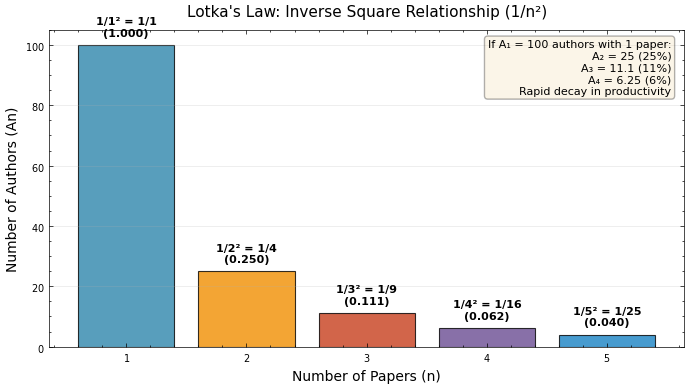

In [12]:
# Create conceptual figure:
# - Show bars for authors with 1, 2, 3, 4 papers
# - Annotate with 1/n² ratios (1, 1/4, 1/9, 1/16)
# - Illustrate rapid decay in author counts
# Save to imgs/01_baseline_{TIMESTAMP}_lotka_concept.png

# Create conceptual figure showing the inverse square relationship

with plt.style.context(['science', 'no-latex', 'nature']):
  fig, ax = plt.subplots(figsize=(7.0, 4.0))

  # Show first 5 values as example
  n_values = np.array([1, 2, 3, 4, 5])
  theoretical_ratios = 1 / (n_values ** 2)

  # Normalize to A1 = 100 for illustration
  A1_example = 100
  theoretical_counts = A1_example * theoretical_ratios

  colors = ['#2E86AB', '#F18F01', '#C73E1D', '#6A4C93', '#1982C4']
  bars = ax.bar(n_values, theoretical_counts, color=colors, alpha=0.8,
                edgecolor='black', linewidth=0.8)

  # Annotate with 1/n² ratios
  for i, (n, ratio, count) in enumerate(zip(n_values, theoretical_ratios, theoretical_counts)):
      # Show the ratio formula
      ax.text(n, count + A1_example*0.03,
              f'1/{n}² = 1/{n**2}\n({ratio:.3f})',
              ha='center', fontsize=8, weight='bold')

  ax.set_xlabel('Number of Papers (n)', fontsize=10)
  ax.set_ylabel('Number of Authors (An)', fontsize=10)
  ax.set_title("Lotka's Law: Inverse Square Relationship (1/n²)", fontsize=11, pad=10)
  ax.set_xticks(n_values)
  ax.grid(axis='y', alpha=0.3)

  # Add annotation explaining the pattern
  ax.text(0.98, 0.97,
          f'If A₁ = {A1_example} authors with 1 paper:\n' +
          f'A₂ = {theoretical_counts[1]:.0f} (25%)\n' +
          f'A₃ = {theoretical_counts[2]:.1f} (11%)\n' +
          f'A₄ = {theoretical_counts[3]:.2f} (6%)\n' +
          'Rapid decay in productivity',
          transform=ax.transAxes, fontsize=8,
          verticalalignment='top', horizontalalignment='right',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

  plt.tight_layout()

  # Save both formats
  filename = f'01_baseline_{TIMESTAMP}_lotka_concept'
  save_figure_both_formats(fig, filename, IMGS_DIR)
  plt.show()

### 3.4 Lotka Distribution: Observed vs. Theoretical (Nature Style)

Compare empirical distribution to theoretical Lotka distribution.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved PNG: imgs/01_baseline_2025-12-08_lotka_fit.png
✅ Saved EPS: imgs/01_baseline_2025-12-08_lotka_fit.eps


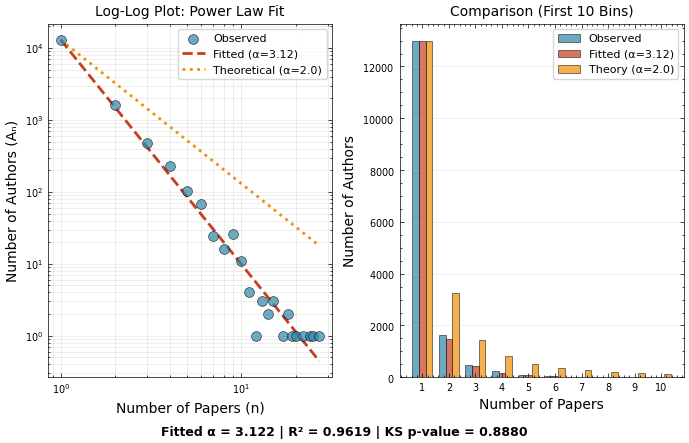

In [13]:
# Create comparison figure:
# - Scatter: observed author counts (log-log scale)
# - Line: fitted power law with estimated α
# - Line: theoretical Lotka (α=2) for comparison
# - Annotate with fitted α, R², and goodness-of-fit p-value
# Save to imgs/01_baseline_{TIMESTAMP}_lotka_fit.png

# Create comparison figure: observed vs theoretical Lotka distribution

with plt.style.context(['science', 'no-latex', 'nature']):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 4.5))

  # Left panel: Log-log plot with fit
  ax1.scatter(fit_data['paper_count'], fit_data['author_count'],
              s=50, alpha=0.7, color='#2E86AB', edgecolors='black', linewidth=0.5,
              label='Observed', zorder=3)

  # Plot fitted line
  papers_range = np.logspace(0, np.log10(fit_data['paper_count'].max()), 100)
  fitted_line = A1 / (papers_range ** alpha)
  ax1.plot(papers_range, fitted_line,
           color='#C73E1D', linewidth=2, linestyle='--',
           label=f'Fitted (α={alpha:.2f})', zorder=2)

  # Plot theoretical Lotka (alpha=2)
  theoretical_line = A1 / (papers_range ** 2)
  ax1.plot(papers_range, theoretical_line,
           color='#F18F01', linewidth=2, linestyle=':',
           label='Theoretical (α=2.0)', zorder=1)

  ax1.set_xlabel('Number of Papers (n)', fontsize=10)
  ax1.set_ylabel('Number of Authors (Aₙ)', fontsize=10)
  ax1.set_title('Log-Log Plot: Power Law Fit', fontsize=10)
  ax1.set_xscale('log')
  ax1.set_yscale('log')
  ax1.legend(frameon=True, fontsize=8)
  ax1.grid(True, alpha=0.3, which='both')

  # Right panel: Linear scale for first 10 productivity levels
  plot_data = fit_data[fit_data['paper_count'] <= 10].copy()

  x_pos = np.arange(len(plot_data))
  width = 0.25

  ax2.bar(x_pos - width, plot_data['author_count'], width,
          label='Observed', color='#2E86AB', alpha=0.7, edgecolor='black', linewidth=0.5)
  ax2.bar(x_pos, plot_data['theoretical_lotka_fitted'], width,
          label=f'Fitted (α={alpha:.2f})', color='#C73E1D', alpha=0.7, edgecolor='black', linewidth=0.5)
  ax2.bar(x_pos + width, plot_data['theoretical_lotka_alpha2'], width,
          label='Theory (α=2.0)', color='#F18F01', alpha=0.7, edgecolor='black', linewidth=0.5)

  ax2.set_xlabel('Number of Papers', fontsize=10)
  ax2.set_ylabel('Number of Authors', fontsize=10)
  ax2.set_title('Comparison (First 10 Bins)', fontsize=10)
  ax2.set_xticks(x_pos)
  ax2.set_xticklabels(plot_data['paper_count'].astype(int))
  ax2.legend(frameon=True, fontsize=8)
  ax2.grid(axis='y', alpha=0.3)

  # Add fit statistics
  fig.text(0.5, 0.02,
           f'Fitted α = {alpha:.3f} | R² = {r_squared:.4f} | KS p-value = {ks_pvalue:.4f}',
           ha='center', fontsize=9, weight='bold')

  plt.tight_layout(rect=[0, 0.04, 1, 1])

  # Save both formats
  filename = f'01_baseline_{TIMESTAMP}_lotka_fit'
  save_figure_both_formats(fig, filename, IMGS_DIR)
  plt.show()

### 3.5 Author Productivity Tiers (Nature Style)

Categorize authors into productivity tiers for interpretability.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



AUTHOR PRODUCTIVITY TIERS
            tier  n_authors  total_papers  pct_authors  pct_papers  avg_papers
    One-time (1)      12996         12996    83.313033   63.370392    1.000000
Occasional (2-5)       2437          6112    15.622796   29.803004    2.508002
  Regular (6-10)        144          1042     0.923136    5.080944    7.236111
      Core (11+)         22           358     0.141035    1.745660   16.272727
✅ Saved PNG: imgs/01_baseline_2025-12-08_author_tiers.png
✅ Saved EPS: imgs/01_baseline_2025-12-08_author_tiers.eps


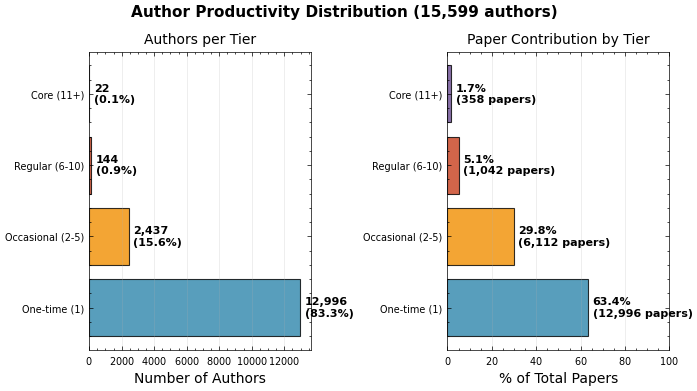


✓ Saved: author_tiers_2025-12-08.csv


In [14]:
# Define tiers:
# - One-time contributors: 1 paper
# - Occasional: 2-5 papers
# - Regular: 6-10 papers
# - Core: 11+ papers
#
# Create bar chart showing:
# - Number of authors per tier
# - Percentage of total authors
# - Contribution to total papers
# Save to imgs/01_baseline_{TIMESTAMP}_author_tiers.png

# Define tiers and create bar chart

# Define productivity tiers
author_productivity['tier'] = pd.cut(
  author_productivity['paper_count'],
  bins=[0, 1, 5, 10, float('inf')],
  labels=['One-time (1)', 'Occasional (2-5)', 'Regular (6-10)', 'Core (11+)'],
  right=True
)

# Count authors per tier
tier_summary = author_productivity.groupby('tier', observed=True).agg(
  n_authors=('author_id', 'count'),
  total_papers=('paper_count', 'sum')
).reset_index()

tier_summary['pct_authors'] = (tier_summary['n_authors'] / total_authors) * 100
total_papers_all = author_productivity['paper_count'].sum()
tier_summary['pct_papers'] = (tier_summary['total_papers'] / total_papers_all) * 100
tier_summary['avg_papers'] = tier_summary['total_papers'] / tier_summary['n_authors']

print("\n" + "="*60)
print("AUTHOR PRODUCTIVITY TIERS")
print("="*60)
print(tier_summary.to_string(index=False))

# Create visualization
with plt.style.context(['science', 'no-latex', 'nature']):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 4.0))

  colors = ['#2E86AB', '#F18F01', '#C73E1D', '#6A4C93']

  # Left panel: Number of authors per tier
  bars1 = ax1.barh(range(len(tier_summary)), tier_summary['n_authors'],
                   color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)
  ax1.set_yticks(range(len(tier_summary)))
  ax1.set_yticklabels(tier_summary['tier'])
  ax1.set_xlabel('Number of Authors', fontsize=10)
  ax1.set_title('Authors per Tier', fontsize=10)
  ax1.grid(axis='x', alpha=0.3)

  # Annotate with percentages
  for i, (count, pct) in enumerate(zip(tier_summary['n_authors'], tier_summary['pct_authors'])):
      ax1.text(count + max(tier_summary['n_authors'])*0.02, i,
              f'{count:,}\n({pct:.1f}%)', va='center', fontsize=8, weight='bold')

  # Right panel: Contribution to total papers
  bars2 = ax2.barh(range(len(tier_summary)), tier_summary['pct_papers'],
                   color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)
  ax2.set_yticks(range(len(tier_summary)))
  ax2.set_yticklabels(tier_summary['tier'])
  ax2.set_xlabel('% of Total Papers', fontsize=10)
  ax2.set_title('Paper Contribution by Tier', fontsize=10)
  ax2.grid(axis='x', alpha=0.3)
  ax2.set_xlim(0, 100)

  # Annotate with percentages
  for i, (papers, pct) in enumerate(zip(tier_summary['total_papers'], tier_summary['pct_papers'])):
      ax2.text(pct + 2, i,
              f'{pct:.1f}%\n({papers:,} papers)', va='center', fontsize=8, weight='bold')

  plt.suptitle(f'Author Productivity Distribution ({total_authors:,} authors)',
               fontsize=11, y=0.98, weight='bold')
  plt.tight_layout()

  # Save both formats
  filename = f'01_baseline_{TIMESTAMP}_author_tiers'
  save_figure_both_formats(fig, filename, IMGS_DIR)
  plt.show()

# Save tier summary
tier_summary.to_csv(OUTPUTS_DIR / f'author_tiers_{TIMESTAMP}.csv', index=False)
print(f"\n✓ Saved: author_tiers_{TIMESTAMP}.csv")

### 3.6 Top Contributors Table

Identify and characterize the most prolific authors.

In [16]:
# Create table of top 20 authors:
# - Author name
# - Number of papers
# - Year range (first → latest publication)
# - Career span (years)
# Save to outputs/top_authors.csv

# Create table of top contributors with career span

# Get top 25 authors
top_authors = author_productivity.nlargest(25, 'paper_count').copy()

# For each top author, get their publication years
author_years = authors_df.groupby('author_id')['pub_year'].agg(['min', 'max', 'count']).reset_index()
author_years.columns = ['author_id', 'first_pub', 'latest_pub', 'papers']
author_years['career_span'] = author_years['latest_pub'] - author_years['first_pub']

# Merge with top authors
top_authors = top_authors.merge(author_years[['author_id', 'first_pub', 'latest_pub', 'career_span']],
                              on='author_id')

# Sort by paper count
top_authors = top_authors.sort_values('paper_count', ascending=False).reset_index(drop=True)
top_authors['rank'] = top_authors.index + 1

print("\n" + "="*60)
print(f"TOP 25 MOST PROLIFIC AUTHORS")
print("="*60)
print(top_authors[['rank', 'full_name', 'paper_count', 'first_pub', 'latest_pub', 'career_span']].to_string(index=False))

# Save to CSV
top_authors.to_csv(OUTPUTS_DIR / f'top_authors_{TIMESTAMP}.csv', index=False)
print(f"\n✓ Saved: top_authors_{TIMESTAMP}.csv")

# Summary statistics
print("\n" + "="*60)
print("TOP CONTRIBUTORS SUMMARY")
print("="*60)
print(f"Average papers (top 25): {top_authors['paper_count'].mean():.1f}")
print(f"Average career span (top 25): {top_authors['career_span'].mean():.1f} years")

# Find longest career
longest_career_idx = top_authors['career_span'].idxmax()
longest_career_years = top_authors['career_span'].max()
longest_career_author = top_authors.loc[longest_career_idx, 'full_name']
print(f"Longest career: {longest_career_years} years ({longest_career_author})")

# Find most prolific
most_prolific_papers = top_authors.iloc[0]['paper_count']
most_prolific_author = top_authors.iloc[0]['full_name']
print(f"Most prolific: {most_prolific_papers} papers ({most_prolific_author})")


TOP 25 MOST PROLIFIC AUTHORS
 rank                 full_name  paper_count  first_pub  latest_pub  career_span
    1          Aggleton, John P           27       2002        2024           22
    2               Witter, M P           25       1982        2020           38
    3              Heinemann, U           24       1986        2015           29
    4          Thompson, Paul M           22       2003        2023           20
    5          Grace, Anthony A           20       2005        2022           17
    6                 Köhler, C           19       1978        1990           12
    7             Behr, Joachim           18       2005        2024           19
    8            Avoli, Massimo           18       2002        2021           19
    9         Dickson, Dennis W           17       2006        2025           19
   10           Witter, Menno P           15       2003        2023           20
   11                  Avoli, M           15       1996        2010           1

---
## Part 4: Geographic Distribution

Analyze the geographic and institutional landscape of subiculum research.

### 4.1 Extract Country/Institution from Affiliations

In [17]:
# Parse affiliation strings to extract:
# - Countries (using keyword matching or regex)
# - Institutions (university names)
# 
# Create country frequency distribution
# Create institution frequency distribution
# Save to outputs/geographic_distribution.csv

# Parse affiliation strings to extract countries and institutions

# Common country keywords for pattern matching
country_patterns = {
  'USA': ['USA', 'United States', 'U.S.A', 'America', r'\bUS\b'],
  'UK': ['United Kingdom', 'England', 'Scotland', 'Wales', 'Britain', r'\bUK\b'],
  'Germany': ['Germany', 'Deutschland'],
  'France': ['France'],
  'Canada': ['Canada'],
  'Japan': ['Japan'],
  'China': ['China', 'P.R. China', "People's Republic of China"],
  'Australia': ['Australia'],
  'Italy': ['Italy', 'Italia'],
  'Netherlands': ['Netherlands', 'Holland'],
  'Spain': ['Spain', 'España'],
  'Switzerland': ['Switzerland', 'Suisse'],
  'Sweden': ['Sweden'],
  'India': ['India'],
  'Brazil': ['Brazil', 'Brasil'],
  'South Korea': ['South Korea', 'Republic of Korea', 'Korea'],
  'Israel': ['Israel'],
  'Austria': ['Austria'],
  'Belgium': ['Belgium'],
  'Denmark': ['Denmark'],
  'Norway': ['Norway'],
  'Finland': ['Finland'],
}

# Extract countries from affiliations
def extract_country(affiliation):
  """Extract country from affiliation string using keyword matching."""
  if pd.isna(affiliation):
      return None

  affiliation_lower = affiliation.lower()

  for country, patterns in country_patterns.items():
      for pattern in patterns:
          if pattern.lower() in affiliation_lower:
              return country

  return 'Other'

# Apply country extraction
authors_df['country'] = authors_df['affiliation'].apply(extract_country)

# Count papers per country (authors can be counted multiple times if on same paper)
country_papers = authors_df.dropna(subset=['country']).groupby('country')['pmid'].nunique().reset_index()
country_papers.columns = ['country', 'paper_count']
country_papers = country_papers.sort_values('paper_count', ascending=False)

# Calculate percentages
total_papers_with_country = country_papers['paper_count'].sum()
country_papers['percentage'] = (country_papers['paper_count'] / total_papers_with_country) * 100

print("="*60)
print("GEOGRAPHIC DISTRIBUTION")
print("="*60)
print(f"Total papers with country information: {total_papers_with_country:,}")
print(f"Unique countries: {len(country_papers):,}")
print(f"\nTop 15 countries:")
print(country_papers.head(15).to_string(index=False))

# Extract institutions (look for University, Institute, Hospital patterns)
import re

def extract_institution(affiliation):
  """Extract institution name from affiliation string."""
  if pd.isna(affiliation):
      return None

  # Common institution patterns
  patterns = [
      r'(University of [A-Z][a-zA-Z\s]+)',
      r'([A-Z][a-zA-Z\s]+ University)',
      r'([A-Z][a-zA-Z\s]+ Institute[s]?)',
      r'([A-Z][a-zA-Z\s]+ Hospital)',
      r'([A-Z][a-zA-Z\s]+ Medical Center)',
      r'([A-Z][a-zA-Z\s]+ College)',
  ]

  for pattern in patterns:
      match = re.search(pattern, affiliation)
      if match:
          return match.group(1).strip()

  return None

# Apply institution extraction
authors_df['institution'] = authors_df['affiliation'].apply(extract_institution)

# Count papers per institution
institution_papers = authors_df.dropna(subset=['institution']).groupby('institution')['pmid'].nunique().reset_index()
institution_papers.columns = ['institution', 'paper_count']
institution_papers = institution_papers.sort_values('paper_count', ascending=False)

print(f"\n\nTop 20 institutions:")
print(institution_papers.head(20).to_string(index=False))

# Save to CSV
country_papers.to_csv(OUTPUTS_DIR / f'geographic_distribution_{TIMESTAMP}.csv', index=False)
institution_papers.to_csv(OUTPUTS_DIR / f'institution_distribution_{TIMESTAMP}.csv', index=False)

print(f"\n✓ Saved: geographic_distribution_{TIMESTAMP}.csv")
print(f"✓ Saved: institution_distribution_{TIMESTAMP}.csv")

GEOGRAPHIC DISTRIBUTION
Total papers with country information: 3,749
Unique countries: 23

Top 15 countries:
    country  paper_count  percentage
        USA         1008   26.887170
      Other          751   20.032009
    Germany          245    6.535076
      Japan          241    6.428381
      China          221    5.894905
     Canada          197    5.254735
     France          162    4.321152
      Spain          105    2.800747
      Italy           95    2.534009
         UK           92    2.453988
Netherlands           91    2.427314
South Korea           81    2.160576
  Australia           63    1.680448
     Brazil           59    1.573753
     Sweden           59    1.573753


Top 20 institutions:
                         institution  paper_count
            University of California          117
                  National Institute           73
                   McGill University           53
      Massachusetts General Hospital           40
                  Cardiff 

### 4.2 Top Countries (Nature Style)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved PNG: imgs/01_baseline_2025-12-08_top_countries.png
✅ Saved EPS: imgs/01_baseline_2025-12-08_top_countries.eps


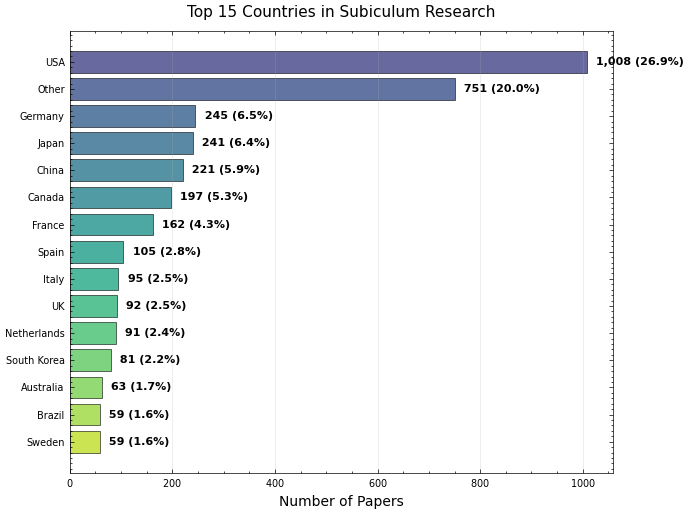

In [18]:
# Create horizontal bar chart:
# - Top 15 countries by paper count
# - Annotate with percentages
# Save to imgs/01_baseline_{TIMESTAMP}_top_countries.png

with plt.style.context(['science', 'no-latex', 'nature']):
  fig, ax = plt.subplots(figsize=(7.0, 5.25))

  # Get top 15 countries
  top_countries = country_papers.head(15).copy()

  # Create horizontal bar chart (reverse order for better readability)
  y_pos = np.arange(len(top_countries))
  colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_countries)))

  bars = ax.barh(y_pos, top_countries['paper_count'],
                 color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

  ax.set_yticks(y_pos)
  ax.set_yticklabels(top_countries['country'])
  ax.invert_yaxis()  # Highest on top
  ax.set_xlabel('Number of Papers', fontsize=10)
  ax.set_title('Top 15 Countries in Subiculum Research', fontsize=11, pad=10)
  ax.grid(axis='x', alpha=0.3)

  # Annotate with counts and percentages
  for i, (count, pct) in enumerate(zip(top_countries['paper_count'], top_countries['percentage'])):
      ax.text(count + max(top_countries['paper_count'])*0.01, i,
              f' {count:,} ({pct:.1f}%)',
              va='center', fontsize=8, weight='bold')

  plt.tight_layout()

  # Save both formats
  filename = f'01_baseline_{TIMESTAMP}_top_countries'
  save_figure_both_formats(fig, filename, IMGS_DIR)
  plt.show()

### 4.3 Top Institutions (Nature Style)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved PNG: imgs/01_baseline_2025-12-08_top_institutions.png
✅ Saved EPS: imgs/01_baseline_2025-12-08_top_institutions.eps


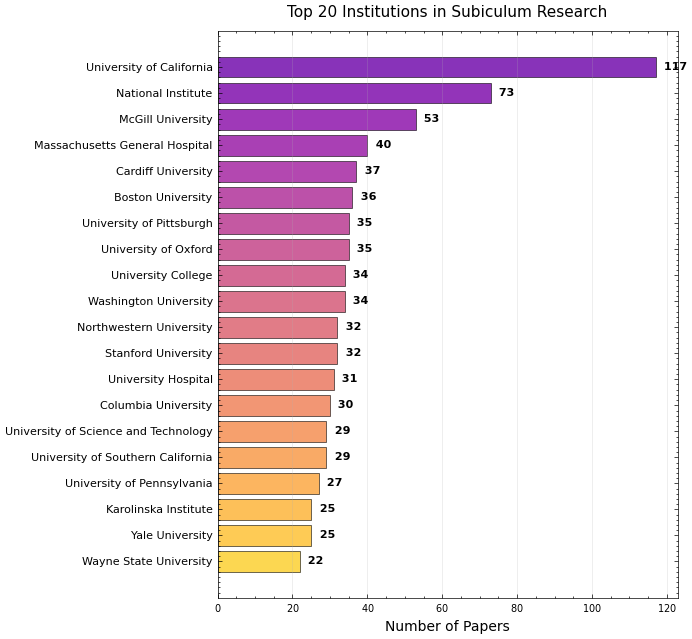

In [19]:
# Create horizontal bar chart:
# - Top 20 institutions by paper count
# - Annotate with country
# Save to imgs/01_baseline_{TIMESTAMP}_top_institutions.png

# Create horizontal bar chart for top institutions

with plt.style.context(['science', 'no-latex', 'nature']):
  fig, ax = plt.subplots(figsize=(7.0, 6.5))

  # Get top 20 institutions
  top_institutions = institution_papers.head(20).copy()

  # Create horizontal bar chart (reverse order for better readability)
  y_pos = np.arange(len(top_institutions))
  colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(top_institutions)))

  bars = ax.barh(y_pos, top_institutions['paper_count'],
                 color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

  # Truncate long institution names for display
  display_names = []
  for inst in top_institutions['institution']:
      if len(inst) > 45:
          display_names.append(inst[:42] + '...')
      else:
          display_names.append(inst)

  ax.set_yticks(y_pos)
  ax.set_yticklabels(display_names, fontsize=8)
  ax.invert_yaxis()  # Highest on top
  ax.set_xlabel('Number of Papers', fontsize=10)
  ax.set_title('Top 20 Institutions in Subiculum Research', fontsize=11, pad=10)
  ax.grid(axis='x', alpha=0.3)

  # Annotate with counts
  for i, count in enumerate(top_institutions['paper_count']):
      ax.text(count + max(top_institutions['paper_count'])*0.01, i,
              f' {count}',
              va='center', fontsize=8, weight='bold')

  plt.tight_layout()

  # Save both formats
  filename = f'01_baseline_{TIMESTAMP}_top_institutions'
  save_figure_both_formats(fig, filename, IMGS_DIR)
  plt.show()

---
## Part 5: Funding Analysis

Characterize funding patterns and major sponsors of subiculum research.

### 5.1 Funding Agency Distribution

In [20]:
# Count papers per funding agency
# Identify top 20 agencies
# Compute percentage of papers with funding vs. no funding
# Save to outputs/funding_distribution.csv

# Count unique papers per agency
funding_counts = grants_df.groupby('agency')['pmid'].nunique().reset_index()
funding_counts.columns = ['agency', 'paper_count']
funding_counts = funding_counts.sort_values('paper_count', ascending=False)

# Calculate percentages
papers_with_funding = grants_df['pmid'].nunique()
papers_without_funding = len(papers_df) - papers_with_funding
funding_pct = (papers_with_funding / len(papers_df)) * 100

funding_counts['percentage'] = (funding_counts['paper_count'] / papers_with_funding) * 100

print("="*60)
print("FUNDING ANALYSIS")
print("="*60)
print(f"Total papers in dataset: {len(papers_df):,}")
print(f"Papers with funding: {papers_with_funding:,} ({funding_pct:.1f}%)")
print(f"Papers without funding: {papers_without_funding:,} ({100-funding_pct:.1f}%)")
print(f"Unique funding agencies: {len(funding_counts):,}")

print(f"\nTop 20 funding agencies:")
print(funding_counts.head(20).to_string(index=False))

# Identify major funding categories
def categorize_funder(agency):
  """Categorize funding agencies into broad categories."""
  agency_lower = str(agency).lower()

  if any(x in agency_lower for x in ['nih', 'national institutes of health', 'ninds', 'nimh', 'nia']):
      return 'NIH (USA)'
  elif any(x in agency_lower for x in ['nsf', 'national science foundation']):
      return 'NSF (USA)'
  elif any(x in agency_lower for x in ['wellcome', 'medical research council', 'mrc', 'bbsrc']):
      return 'UK Research Councils'
  elif any(x in agency_lower for x in ['dfg', 'deutsche forschungsgemeinschaft']):
      return 'DFG (Germany)'
  elif any(x in agency_lower for x in ['nserc', 'cihr', 'canada']):
      return 'Canada Research'
  elif any(x in agency_lower for x in ['national natural science foundation', 'nsfc', 'china']):
      return 'NSFC (China)'
  elif any(x in agency_lower for x in ['jsps', 'japan society']):
      return 'JSPS (Japan)'
  elif any(x in agency_lower for x in ['anr', 'inserm', 'cnrs']):
      return 'France Research'
  elif any(x in agency_lower for x in ['european', 'eu ', 'horizon', 'erc']):
      return 'EU Programs'
  else:
      return 'Other'

grants_df['funder_category'] = grants_df['agency'].apply(categorize_funder)

# Count by category
category_counts = grants_df.groupby('funder_category')['pmid'].nunique().reset_index()
category_counts.columns = ['category', 'paper_count']
category_counts = category_counts.sort_values('paper_count', ascending=False)
category_counts['percentage'] = (category_counts['paper_count'] / papers_with_funding) * 100

print(f"\n\nFunding by major categories:")
print(category_counts.to_string(index=False))

# Save to CSV
funding_counts.to_csv(OUTPUTS_DIR / f'funding_distribution_{TIMESTAMP}.csv', index=False)
category_counts.to_csv(OUTPUTS_DIR / f'funding_categories_{TIMESTAMP}.csv', index=False)

print(f"\n✓ Saved: funding_distribution_{TIMESTAMP}.csv")
print(f"✓ Saved: funding_categories_{TIMESTAMP}.csv")

FUNDING ANALYSIS
Total papers in dataset: 3,572
Papers with funding: 1,506 (42.2%)
Papers without funding: 2,066 (57.8%)
Unique funding agencies: 382

Top 20 funding agencies:
                                      agency  paper_count  percentage
                               NINDS NIH HHS          440   29.216467
                                NIMH NIH HHS          394   26.162019
                                 NIA NIH HHS          384   25.498008
                              Wellcome Trust          120    7.968127
                                NIDA NIH HHS          107    7.104914
                               NICHD NIH HHS           92    6.108898
                                NCRR NIH HHS           88    5.843293
                    Medical Research Council           70    4.648074
                               NIGMS NIH HHS           68    4.515272
                               NIBIB NIH HHS           63    4.183267
                                     NIH HHS          

### 5.2 Top Funding Agencies (Nature Style)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved PNG: imgs/01_baseline_2025-12-08_top_funders.png
✅ Saved EPS: imgs/01_baseline_2025-12-08_top_funders.eps


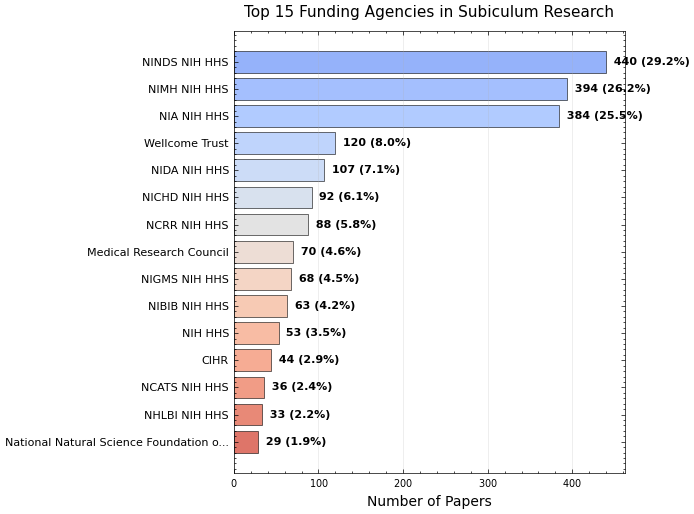

In [21]:
# Create horizontal bar chart:
# - Top 15 funding agencies
# - Annotate with country (if available)
# Save to imgs/01_baseline_{TIMESTAMP}_top_funders.png

# Create horizontal bar chart for top funding agencies

with plt.style.context(['science', 'no-latex', 'nature']):
  fig, ax = plt.subplots(figsize=(7.0, 5.25))

  # Get top 15 agencies
  top_funders = funding_counts.head(15).copy()

  # Create horizontal bar chart (reverse order for better readability)
  y_pos = np.arange(len(top_funders))
  colors = plt.cm.coolwarm(np.linspace(0.2, 0.9, len(top_funders)))

  bars = ax.barh(y_pos, top_funders['paper_count'],
                 color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

  # Truncate long agency names for display
  display_names = []
  for agency in top_funders['agency']:
      agency_str = str(agency)
      if len(agency_str) > 40:
          display_names.append(agency_str[:37] + '...')
      else:
          display_names.append(agency_str)

  ax.set_yticks(y_pos)
  ax.set_yticklabels(display_names, fontsize=8)
  ax.invert_yaxis()  # Highest on top
  ax.set_xlabel('Number of Papers', fontsize=10)
  ax.set_title('Top 15 Funding Agencies in Subiculum Research', fontsize=11, pad=10)
  ax.grid(axis='x', alpha=0.3)

  # Annotate with counts and percentages
  for i, (count, pct) in enumerate(zip(top_funders['paper_count'], top_funders['percentage'])):
      ax.text(count + max(top_funders['paper_count'])*0.01, i,
              f' {count} ({pct:.1f}%)',
              va='center', fontsize=8, weight='bold')

  plt.tight_layout()

  # Save both formats
  filename = f'01_baseline_{TIMESTAMP}_top_funders'
  save_figure_both_formats(fig, filename, IMGS_DIR)
  plt.show()

### 5.3 Funding Over Time

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved PNG: imgs/01_baseline_2025-12-08_funding_trends.png
✅ Saved EPS: imgs/01_baseline_2025-12-08_funding_trends.eps


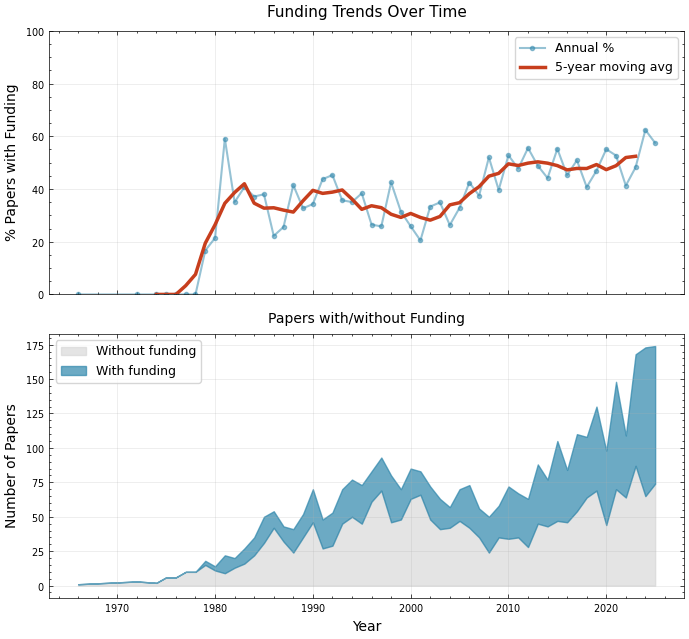


✓ Saved: funding_trends_2025-12-08.csv

FUNDING TRENDS SUMMARY
Overall funding rate: 42.2%
Recent decade (last 10 years) funding rate: 50.1%
Peak funding year: 2024 (62.4%)


In [23]:
# Plot percentage of papers with funding over time
# - Line plot showing temporal trend
# - Stacked area chart showing major funders over time (optional)
# Save to imgs/01_baseline_{TIMESTAMP}_funding_trends.png

 # Plot percentage of papers with funding over time

# Calculate papers with/without funding per year
papers_per_year = papers_df.groupby('pub_year').size().reset_index(name='total_papers')
funded_per_year = grants_df.groupby('pub_year')['pmid'].nunique().reset_index(name='funded_papers')

funding_trends = papers_per_year.merge(funded_per_year, on='pub_year', how='left')
funding_trends['funded_papers'] = funding_trends['funded_papers'].fillna(0)
funding_trends['unfunded_papers'] = funding_trends['total_papers'] - funding_trends['funded_papers']
funding_trends['funding_percentage'] = (funding_trends['funded_papers'] / funding_trends['total_papers']) * 100

# Calculate 5-year moving average
funding_trends['funding_pct_ma5'] = funding_trends['funding_percentage'].rolling(window=5, center=True).mean()

with plt.style.context(['science', 'no-latex', 'nature']):
  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 6.5), sharex=True)

  # Top panel: Percentage with funding over time
  ax1.plot(funding_trends['pub_year'], funding_trends['funding_percentage'],
           marker='o', markersize=3, linewidth=1.5, alpha=0.5,
           color='#2E86AB', label='Annual %')
  ax1.plot(funding_trends['pub_year'], funding_trends['funding_pct_ma5'],
           linewidth=2.5, color='#C73E1D',
           label='5-year moving avg')

  ax1.set_ylabel('% Papers with Funding', fontsize=10)
  ax1.set_title('Funding Trends Over Time', fontsize=11, pad=10)
  ax1.legend(frameon=True, fontsize=9, loc='best')
  ax1.grid(True, alpha=0.3)
  ax1.set_ylim(0, 100)

  # Bottom panel: Stacked area showing funded vs unfunded
  ax2.fill_between(funding_trends['pub_year'], 0, funding_trends['unfunded_papers'],
                   color='#D3D3D3', alpha=0.6, label='Without funding')
  ax2.fill_between(funding_trends['pub_year'], funding_trends['unfunded_papers'],
                   funding_trends['total_papers'],
                   color='#2E86AB', alpha=0.7, label='With funding')

  ax2.set_xlabel('Year', fontsize=10)
  ax2.set_ylabel('Number of Papers', fontsize=10)
  ax2.set_title('Papers with/without Funding', fontsize=10, pad=8)
  ax2.legend(frameon=True, fontsize=9, loc='upper left')
  ax2.grid(True, alpha=0.3)

  plt.tight_layout()

  # Save both formats
  filename = f'01_baseline_{TIMESTAMP}_funding_trends'
  save_figure_both_formats(fig, filename, IMGS_DIR)
  plt.show()

# Save funding trends data
funding_trends.to_csv(OUTPUTS_DIR / f'funding_trends_{TIMESTAMP}.csv', index=False)
print(f"\n✓ Saved: funding_trends_{TIMESTAMP}.csv")

# Print summary statistics
recent_decade = funding_trends[funding_trends['pub_year'] >= funding_trends['pub_year'].max() - 9]
print("\n" + "="*60)
print("FUNDING TRENDS SUMMARY")
print("="*60)
print(f"Overall funding rate: {funding_pct:.1f}%")
print(f"Recent decade (last 10 years) funding rate: {recent_decade['funding_percentage'].mean():.1f}%")
print(f"Peak funding year: {funding_trends.loc[funding_trends['funding_percentage'].idxmax(), 'pub_year']:.0f} ({funding_trends['funding_percentage'].max():.1f}%)")

---
## Part 6: Summary Statistics & JSON Export

Compile key statistics for reproducibility and potential dashboard integration.

In [25]:
# Create summary dictionary with:
# - Total papers, year range
# - Bradford zones: n_journals, n_articles, multiplier
# - Lotka: α, R², one-time contributor %
# - Top 5 journals, authors, countries, funders
# - Publication rate: papers per year (recent 5 years)
#
# Save to outputs/landscape_summary.json


# Create summary dictionary with all key statistics

summary_stats = {
  "metadata": {
      "analysis_date": TIMESTAMP,
      "database": str(DB_PATH),
      "total_papers": int(len(papers_df)),
      "year_range": {
          "min": int(papers_df['pub_year'].min()),
          "max": int(papers_df['pub_year'].max()),
          "span": int(papers_df['pub_year'].max() - papers_df['pub_year'].min())
      }
  },

  "publication_trends": {
      "total_papers": int(len(papers_df)),
      "recent_5yr_count": int(recent_5yr_count),
      "recent_5yr_avg": float(recent_5yr_avg),
      "peak_year": int(papers_by_year.loc[papers_by_year['count'].idxmax(), 'pub_year']),
      "peak_count": int(papers_by_year['count'].max())
  },

  "bradford_law": {
      "total_journals": int(n_journals),
      "zone1": {
          "journals": int(zone1_journals),
          "papers": int(zone1_papers),
          "papers_pct": float(zone1_papers/total_papers*100)
      },
      "zone2": {
          "journals": int(zone2_journals),
          "papers": int(zone2_papers),
          "papers_pct": float(zone2_papers/total_papers*100)
      },
      "zone3": {
          "journals": int(zone3_journals),
          "papers": int(zone3_papers),
          "papers_pct": float(zone3_papers/total_papers*100)
      },
      "bradford_multiplier": float((bradford_multiplier_1 + bradford_multiplier_2) / 2),
      "multiplier_1": float(bradford_multiplier_1),
      "multiplier_2": float(bradford_multiplier_2),
      "core_journals": journal_counts[journal_counts['zone'] == 1]['journal_name'].tolist()[:10]
  },

  "lotka_law": {
      "total_authors": int(total_authors),
      "fitted_alpha": float(alpha),
      "theoretical_alpha": 2.0,
      "r_squared": float(r_squared),
      "ks_pvalue": float(ks_pvalue),
      "one_time_contributors": {
          "count": int(one_time),
          "percentage": float(one_time_pct)
      },
      "productivity_tiers": {
          "one_time": {
              "authors": int(tier_summary[tier_summary['tier'] == 'One-time (1)']['n_authors'].values[0]),
              "percentage": float(tier_summary[tier_summary['tier'] == 'One-time (1)']['pct_authors'].values[0])
          },
          "occasional": {
              "authors": int(tier_summary[tier_summary['tier'] == 'Occasional (2-5)']['n_authors'].values[0]),
              "percentage": float(tier_summary[tier_summary['tier'] == 'Occasional (2-5)']['pct_authors'].values[0])
          },
          "regular": {
              "authors": int(tier_summary[tier_summary['tier'] == 'Regular (6-10)']['n_authors'].values[0]),
              "percentage": float(tier_summary[tier_summary['tier'] == 'Regular (6-10)']['pct_authors'].values[0])
          },
          "core": {
              "authors": int(tier_summary[tier_summary['tier'] == 'Core (11+)']['n_authors'].values[0]),
              "percentage": float(tier_summary[tier_summary['tier'] == 'Core (11+)']['pct_authors'].values[0])
          }
      },
      "top_5_authors": [
          {
              "name": row['full_name'],
              "papers": int(row['paper_count']),
              "career_span": int(row['career_span'])
          }
          for _, row in top_authors.head(5).iterrows()
      ]
  },

  "geographic_distribution": {
      "total_countries": int(len(country_papers)),
      "papers_with_country_info": int(total_papers_with_country),
      "top_5_countries": [
          {
              "country": row['country'],
              "papers": int(row['paper_count']),
              "percentage": float(row['percentage'])
          }
          for _, row in country_papers.head(5).iterrows()
      ],
      "top_5_institutions": [
          {
              "institution": row['institution'],
              "papers": int(row['paper_count'])
          }
          for _, row in institution_papers.head(5).iterrows()
      ]
  },

  "funding_analysis": {
      "papers_with_funding": int(papers_with_funding),
      "papers_without_funding": int(papers_without_funding),
      "funding_percentage": float(funding_pct),
      "total_agencies": int(len(funding_counts)),
      "recent_decade_funding_pct": float(recent_decade['funding_percentage'].mean()),
      "top_5_funders": [
          {
              "agency": row['agency'],
              "papers": int(row['paper_count']),
              "percentage": float(row['percentage'])
          }
          for _, row in funding_counts.head(5).iterrows()
      ],
      "major_categories": [
          {
              "category": row['category'],
              "papers": int(row['paper_count']),
              "percentage": float(row['percentage'])
          }
          for _, row in category_counts.iterrows()
      ]
  },

  "field_characteristics": {
      "concentration": {
          "core_journals_percentage": float(zone1_journals / n_journals * 100),
          "core_authors_percentage": float(tier_summary[tier_summary['tier'] == 'Core (11+)']['pct_authors'].values[0])
      },
      "internationalization": {
          "countries_represented": int(len(country_papers)),
          "top_country_dominance": float(country_papers.iloc[0]['percentage'])
      },
      "maturity": {
          "years_active": int(papers_df['pub_year'].max() - papers_df['pub_year'].min()),
          "recent_growth": "accelerating" if recent_5yr_avg > papers_by_year['count'].mean() else "stable"
      }
  }
}

# Save to JSON with pretty formatting
json_path = OUTPUTS_DIR / f'landscape_summary_{TIMESTAMP}.json'
with open(json_path, 'w') as f:
  json.dump(summary_stats, f, indent=2, ensure_ascii=False)

print("\n" + "="*80)
print("SUMMARY STATISTICS EXPORTED")
print("="*80)
print(f"✓ Saved: {json_path.name}")
print(f"\nSummary includes:")
print("  - Publication trends and growth patterns")
print("  - Bradford's Law: journal distribution (multiplier: {:.2f})".format(summary_stats['bradford_law']['bradford_multiplier']))
print("  - Lotka's Law: author productivity (α={:.3f}, R²={:.4f})".format(alpha, r_squared))
print("  - Geographic distribution ({} countries)".format(len(country_papers)))
print("  - Funding analysis ({:.1f}% papers with funding)".format(funding_pct))
print("  - Field characteristics and maturity indicators")

# Pretty print key findings
print("\n" + "="*80)
print("KEY FINDINGS SUMMARY")
print("="*80)

print("\n PUBLICATION LANDSCAPE")
print(f"  • Total papers: {len(papers_df):,} ({papers_df['pub_year'].min()}-{papers_df['pub_year'].max()})")
print(f"  • Recent 5 years: {recent_5yr_avg:.1f} papers/year")
print(f"  • Total journals: {n_journals:,}")
print(f"  • Total authors: {total_authors:,}")

print("\n BRADFORD'S LAW (Journal Distribution)")
print(f"  • Core journals (Zone 1): {zone1_journals} journals → {zone1_papers} papers ({zone1_papers/total_papers*100:.1f}%)")
print(f"  • Bradford multiplier: n ≈ {(bradford_multiplier_1 + bradford_multiplier_2)/2:.2f}")
print(f"  • Top journal: {journal_counts.iloc[0]['journal_name']} ({journal_counts.iloc[0]['paper_count']} papers)")

print("\n LOTKA'S LAW (Author Productivity)")
print(f"  • Fitted exponent: α = {alpha:.3f} (theoretical: 2.0)")
print(f"  • Model fit: R² = {r_squared:.4f}")
print(f"  • One-time contributors: {one_time:,} authors ({one_time_pct:.1f}%)")
print(f"  • Core contributors (11+ papers): {tier_summary[tier_summary['tier'] == 'Core (11+)']['n_authors'].values[0]} authors")
print(f"  • Most prolific: {top_authors.iloc[0]['full_name']} ({top_authors.iloc[0]['paper_count']} papers)")

print("\n GEOGRAPHIC DISTRIBUTION")
print(f"  • Countries represented: {len(country_papers):,}")
print(f"  • Top country: {country_papers.iloc[0]['country']} ({country_papers.iloc[0]['percentage']:.1f}%)")
print(f"  • Top institution: {institution_papers.iloc[0]['institution']} ({institution_papers.iloc[0]['paper_count']} papers)")

print("\n FUNDING ANALYSIS")
print(f"  • Papers with funding: {papers_with_funding:,} ({funding_pct:.1f}%)")
print(f"  • Unique funding agencies: {len(funding_counts):,}")
print(f"  • Top funder: {funding_counts.iloc[0]['agency']} ({funding_counts.iloc[0]['paper_count']} papers)")
print(f"  • Recent decade funding rate: {recent_decade['funding_percentage'].mean():.1f}%")

print("\n" + "="*80)


SUMMARY STATISTICS EXPORTED
✓ Saved: landscape_summary_2025-12-08.json

Summary includes:
  - Publication trends and growth patterns
  - Bradford's Law: journal distribution (multiplier: 6.76)
  - Lotka's Law: author productivity (α=3.122, R²=0.9619)
  - Geographic distribution (23 countries)
  - Funding analysis (42.2% papers with funding)
  - Field characteristics and maturity indicators

KEY FINDINGS SUMMARY

 PUBLICATION LANDSCAPE
  • Total papers: 3,572 (1966-2025)
  • Recent 5 years: 154.4 papers/year
  • Total journals: 592
  • Total authors: 15,599

 BRADFORD'S LAW (Journal Distribution)
  • Core journals (Zone 1): 12 journals → 1218 papers (34.1%)
  • Bradford multiplier: n ≈ 6.76
  • Top journal: Brain research (218 papers)

 LOTKA'S LAW (Author Productivity)
  • Fitted exponent: α = 3.122 (theoretical: 2.0)
  • Model fit: R² = 0.9619
  • One-time contributors: 12,996 authors (83.3%)
  • Core contributors (11+ papers): 22 authors
  • Most prolific: Aggleton, John P (27 paper

---
## Summary & Key Findings

### Bradford's Law Results
- Core journals (Zone 1): [X journals contribute Y articles]
- Bradford multiplier: n = [estimated value]
- Interpretation: [explain diminishing returns in literature searching]

### Lotka's Law Results
- Fitted exponent: α = [estimated value] (theoretical: 2.0)
- One-time contributors: [X%]
- Core contributors (10+ papers): [Y authors, Z%]
- Interpretation: [explain productivity distribution]

### Geographic & Funding Landscape
- Dominant countries: [list]
- Major institutions: [list]
- Primary funders: [list]

### Field Characteristics
- [Summarize maturity, concentration, internationalization]
- [Compare to typical bibliometric patterns]
- [Implications for literature review strategy]

---
## Cleanup

In [ ]:
# Close database connection
conn.close()

print("\n" + "="*80)
print("Analysis complete!")
print("="*80)
print(f"Figures saved to: {IMGS_DIR}")
print(f"Data outputs saved to: {OUTPUTS_DIR}")
print(f"\nNext step: Compile LaTeX report (01_baseline_report.tex)")